In [1]:
a=22
a

22

In [2]:
type(a)

int

In [3]:
b=55
b

55

In [4]:
type(b)

int

In [5]:
import cv2

# Load the Haar cascade files for face and eye detection
face_cascade = cv2.CascadeClassifier(cv2.data.haarcascades + 'haarcascade_frontalface_default.xml')
eye_cascade = cv2.CascadeClassifier(cv2.data.haarcascades + 'haarcascade_eye.xml')

# Start the video capture
cap = cv2.VideoCapture(0)  # 0 for the default webcam

while True:
    # Read the frame from the webcam
    ret, frame = cap.read()
    
    if not ret:
        print("Failed to capture video")
        break

    # Convert the frame to grayscale for better accuracy
    gray = cv2.cvtColor(frame, cv2.COLOR_BGR2GRAY)

    # Detect faces in the frame
    faces = face_cascade.detectMultiScale(gray, scaleFactor=1.3, minNeighbors=5, minSize=(30, 30))

    for (x, y, w, h) in faces:
        # Draw a rectangle around the face
        cv2.rectangle(frame, (x, y), (x+w, y+h), (255, 0, 0), 2)
        roi_gray = gray[y:y+h, x:x+w]
        roi_color = frame[y:y+h, x:x+w]

        # Detect eyes within the face region
        eyes = eye_cascade.detectMultiScale(roi_gray, scaleFactor=1.1, minNeighbors=10, minSize=(15, 15))
        for (ex, ey, ew, eh) in eyes:
            cv2.rectangle(roi_color, (ex, ey), (ex+ew, ey+eh), (0, 255, 0), 2)

    # Display the frame with rectangles
    cv2.imshow('Face and Eye Detection', frame)

    # Break the loop when 'q' is pressed
    if cv2.waitKey(1) & 0xFF == ord('q'):
        break

# Release the video capture and close all OpenCV windows
cap.release()
cv2.destroyAllWindows()


Mean Squared Error: 1.3311905469678869
R-Squared: 0.9966720236325802


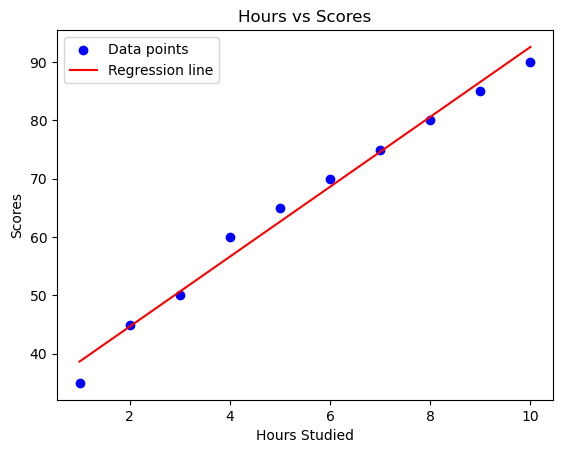

Predicted Score for 6.5 hours of study: 71.61637931034483


E:\Anaconda\Lib\site-packages\sklearn\base.py:493: UserWarning: X does not have valid feature names, but LinearRegression was fitted with feature names
  warnings.warn(


In [6]:
# Import necessary libraries
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_squared_error, r2_score

# Step 1: Prepare the dataset
# Sample data (Hours studied vs Exam Scores)
data = {'Hours': [1, 2, 3, 4, 5, 6, 7, 8, 9, 10],
        'Scores': [35, 45, 50, 60, 65, 70, 75, 80, 85, 90]}

# Convert the data into a pandas DataFrame
df = pd.DataFrame(data)

# Step 2: Preprocess the data
# Split the dataset into input (X) and output (y)
X = df[['Hours']]  # Independent variable (Hours)
y = df['Scores']   # Dependent variable (Scores)

# Split the data into training and testing sets
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# Step 3: Train the model
# Initialize and train the Linear Regression model
model = LinearRegression()
model.fit(X_train, y_train)

# Step 4: Predict and evaluate the model
# Make predictions on the test set
y_pred = model.predict(X_test)

# Evaluate the model using Mean Squared Error and R-Squared
mse = mean_squared_error(y_test, y_pred)
r2 = r2_score(y_test, y_pred)

print(f'Mean Squared Error: {mse}')
print(f'R-Squared: {r2}')

# Visualize the training data and the regression line
plt.scatter(X, y, color='blue', label='Data points')
plt.plot(X, model.predict(X), color='red', label='Regression line')
plt.title('Hours vs Scores')
plt.xlabel('Hours Studied')
plt.ylabel('Scores')
plt.legend()
plt.show()

# Predict a new value (for example, predicting score for 6.5 hours of study)
new_hours = np.array([[6.5]])
predicted_score = model.predict(new_hours)
print(f'Predicted Score for 6.5 hours of study: {predicted_score[0]}')
